<a href="https://colab.research.google.com/github/Stefano2608/Topicos-Especiais-D---IA/blob/main/mnist_01_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:

import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

digits = test_images.copy()

train_images = train_images.reshape((60000, 28*28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28*28))
test_images = test_images.astype("float32") / 255


In [22]:

import keras
from keras import layers

batch_size = 256
epochs = 480

model = keras.Sequential(
    [
      layers.Dense(1024, activation="relu"),
      layers.Dropout(0.6),
      layers.Dense(512, activation="relu"),
      layers.Dropout(0.4),
      layers.Dense(256, activation="relu"),
      layers.Dense(10, activation="softmax"),
    ]
)


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=120,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    filepath=f"mnist_dense_b{batch_size}e{epochs}_last.keras",
    monitor="val_loss",
    save_best_only=True,
)

optimizer = Adam(learning_rate=0.0005)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


history = model.fit(
    train_images,
    train_labels,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    callbacks = [model_checkpoint, early_stop] # -> , early_stop opcional
)

model = keras.models.load_model(f"mnist_dense_b{batch_size}e{epochs}_last.keras")

test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"test_acc: {test_acc}")

Epoch 1/480
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8388 - loss: 0.5205 - val_accuracy: 0.9452 - val_loss: 0.1808
Epoch 2/480
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9380 - loss: 0.2049 - val_accuracy: 0.9606 - val_loss: 0.1281
Epoch 3/480
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9533 - loss: 0.1537 - val_accuracy: 0.9693 - val_loss: 0.1058
Epoch 4/480
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9623 - loss: 0.1224 - val_accuracy: 0.9713 - val_loss: 0.0935
Epoch 5/480
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9668 - loss: 0.1055 - val_accuracy: 0.9725 - val_loss: 0.0898
Epoch 6/480
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9708 - loss: 0.0929 - val_accuracy: 0.9754 - val_loss: 0.0805
Epoch 7/480
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9732 - loss: 0.0845 - val_accuracy: 0.9768 - val_loss: 0.0772
Epoch 8/480
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9750 - loss: 0.0776 - val_acc

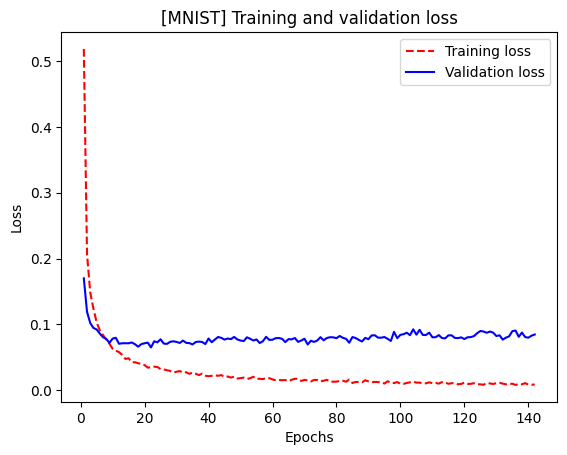

In [11]:
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("[MNIST] Training and validation loss")
plt.xlabel("Epochs")
plt.xticks()
plt.ylabel("Loss")
plt.legend()
plt.show()

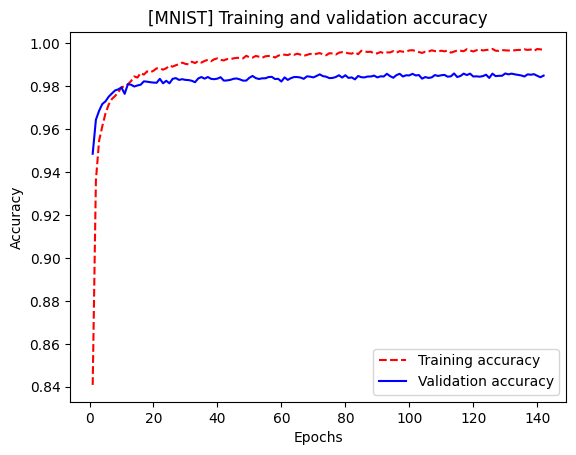

In [12]:
loss_values = history_dict["accuracy"]
val_loss_values = history_dict["val_accuracy"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training accuracy")
plt.plot(epochs, val_loss_values, "b", label="Validation accuracy")
plt.title("[MNIST] Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks()
plt.ylabel("Accuracy")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Model Prediction: 2
Actual Label: 2


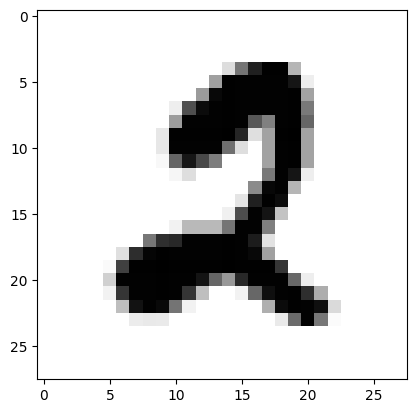

In [21]:
import random

def compare_prediction(idx):
    image_predict = test_images[idx]
    prediction = model.predict(image_predict[np.newaxis, :])
    predicted_digit = np.argmax(prediction)
    actual_digit = test_labels[idx]

    print(f"Model Prediction: {predicted_digit}")
    print(f"Actual Label: {actual_digit}")

    digit = digits[idx]
    plt.imshow(digit, cmap=plt.cm.binary)
    plt.show()

digit = random.randint(0, 9999)
compare_prediction(digit)
